In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load the dataset
url = "https://raw.githubusercontent.com/ravin508/ml-assessment-ravindra-hegde/main/data/q2_customers.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())
print(df.describe())

Shape: (500, 6)
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  
             age   annual_spend  visits_per_month  basket_size  \
count  500.00000     500.000000        500.000000   500.000000   
mean    40.45200   48856.948000          8.414000  2682.286000   
std     14.42664   32856.795353          5.324595  2274.957339   
min     18.00000    5038.000000          1.000000   212.000000   
25%  

### Why scaling is essential before applying K-Means

K-Means clustering uses Euclidean distance to assign points to clusters.  
The features in this dataset have very different scales:

- `annual_spend` and `basket_size` are in thousands  
- `age` is in tens  
- `visits_per_month` and `days_since_last_visit` are small integers  

Without scaling, high-magnitude features (spend/basket) would dominate the distance calculations, making the clusters meaningless.  
`StandardScaler` transforms every feature to mean = 0 and standard deviation = 1, so all variables contribute equally.

In [2]:
# Scale the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

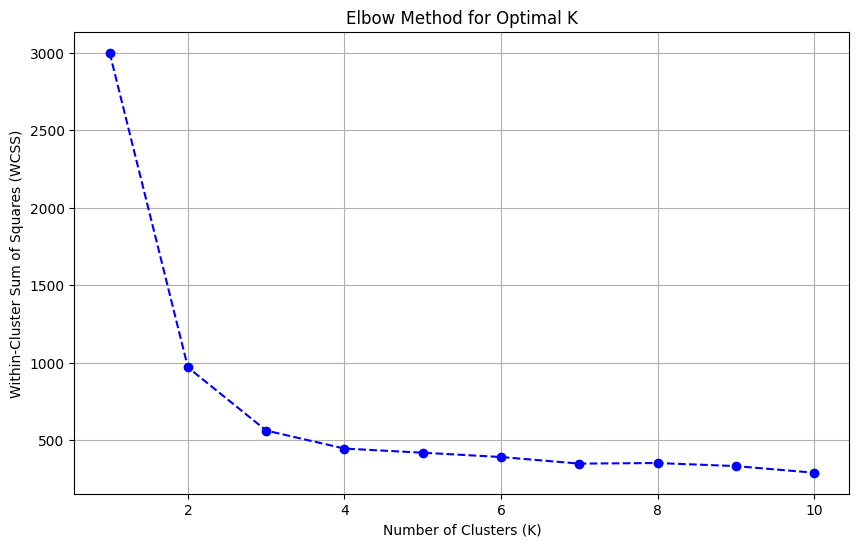

In [3]:
# Compute WCSS for K = 1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the elbow
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

### Choosing K — Elbow Method

The elbow plot shows a clear bend at **K=3**. After K=3 the WCSS decreases very slowly (the curve becomes almost flat).  
Therefore, the optimal number of clusters is **K=3**.

In [4]:
# Fit K-Means with chosen K=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(scaled_data)

# Cluster sizes
print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

# Centroids in original scale
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)
centroids.index.name = "Cluster"
print("\nCluster Centroids:")
print(centroids.round(2))

Cluster sizes:
cluster
0    170
1    165
2    165
Name: count, dtype: int64

Cluster Centroids:
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        56.77      89413.33              2.53      5530.55   
2        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       105.36                      7.52  
2                        35.19                      4.42  


### Business Interpretation of the Clusters (K=3)

- **Cluster 0** (≈170 customers): Young customers (avg age ≈24.7), very low annual spend (≈$14,847), extremely high visit frequency (≈14.3 visits/month), very small basket size (≈$559), and highly recent activity.  
  → **Young Frequent Budget Shoppers** — high engagement but low spending power.

- **Cluster 1** (≈165 customers): Middle-aged customers (avg age ≈40.4), medium annual spend (≈$43,341), balanced visit frequency (≈8.2 visits/month), medium basket size (≈$2,022).  
  → **Average Balanced Everyday Customers** — the stable core segment.

- **Cluster 2** (≈165 customers): Older customers (avg age ≈57.1), very high annual spend (≈$89,778), low visit frequency (≈2.5 visits/month), very large basket size (≈$5,346), long inactivity (≈147 days).  
  → **Premium High-Value Customers (At-Risk)** — high spending but showing signs of churn. Targeted re-engagement is recommended.

Explained variance ratio: [0.8356 0.0557]

Feature Loadings:
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


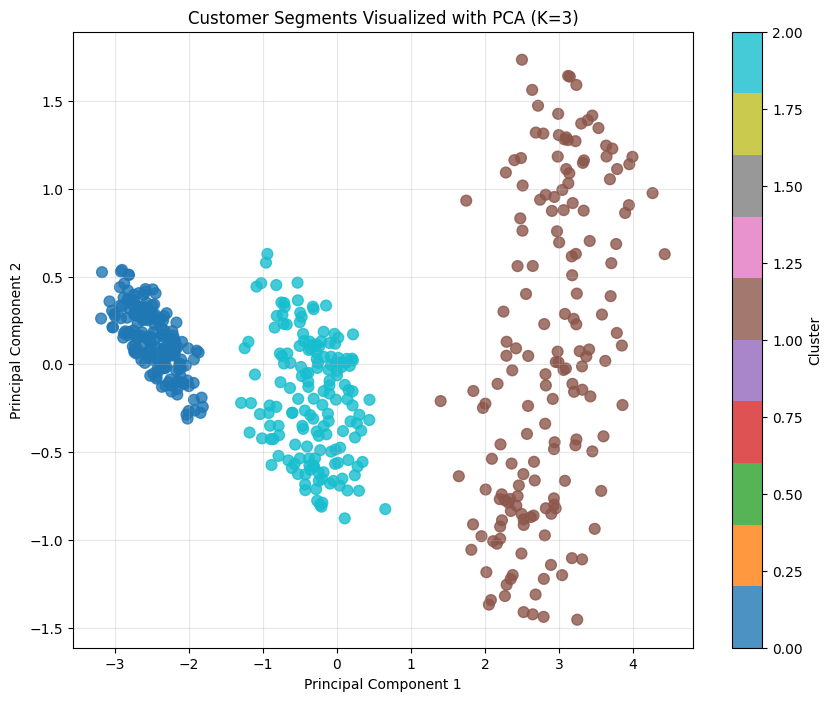

In [5]:
# PCA to 2 components
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_data)

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_.round(4))

# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)
print("\nFeature Loadings:")
print(loadings.round(4))

# Scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1],
                      c=df['cluster'], cmap='tab10', alpha=0.8, s=60)
plt.title('Customer Segments Visualized with PCA (K=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

### PCA Interpretation

- **PC1** explains ~83.5% of the total variance. It has strong positive loadings on `annual_spend`, `basket_size`, `num_categories_purchased`, and `age`, and a strong negative loading on `visits_per_month`.  
  → **PC1 represents "Customer Value & Maturity"** — it separates high-spending, older customers with large baskets from young, frequent, low-spending visitors.

- **PC2** explains ~5.6% of the variance and is dominated by a very high positive loading on `days_since_last_visit`.  
  → **PC2 represents "Recency / Inactivity"** — higher values indicate customers who have not visited for a long time (potential churn risk).